# 1. Baseline LLM: Comparisons between control and gamified tool unlock

This notebook analyzes the `GAIA` question performance of the baseline LLM vs GAMIFIED tool system across multiple seeds (42, 43, 44).

It addresses:
- Compare difference in question selection (based off category and level): All
- Compare overall accuracy: All
- Compare category accuracy: All
- Compare question category selection: All

In [33]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

# Load parsed data
with open('../scripts/parsed_data.json', 'r') as f:
    data = json.load(f)

questions = []
for run in data:
    for q in run['questions_attempted']:
        questions.append(q)

df_run = pd.DataFrame([{
    'seed': r['seed'],
    'mode': r['mode'],
    'rooms_visited': r['final_state'].get('rooms_visited', 0),
    'correct_count': r['final_state'].get('correct_count', 0),
    'wrong_count': r['final_state'].get('wrong_count', 0),
    'skills_unlocked_count': r['final_state'].get('skills_unlocked_count', 0)
} for r in data])

df_q = pd.DataFrame(questions)
df_q['is_correct'] = df_q['is_correct'].astype(int)
display(df_run)

,seed,mode,rooms_visited,correct_count,wrong_count,skills_unlocked_count
0,46,tool,9,4,5,3
1,71,control,6,2,4,0
2,57,tool,4,0,4,0
3,53,control,6,2,4,0
4,66,tool,8,4,4,3
...,...,...,...,...,...,...
151,84,tool,7,2,5,2
152,80,tool,8,4,4,3
153,83,control,8,3,5,0
154,105,control,8,3,5,0


## 1.1 Compare overall accuracy: All

--- Overall Statistical Test Results ---


,Comparison,control Acc (%),tool Acc (%),control (N),tool (N),Diff (% pts),Z-Score,P-Value,Significant?
0,control vs tool,42.01,42.99,557,542,0.98,-0.328,0.742944,No


/tmp/ipykernel_263977/465567813.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=overall_accuracy, x='mode', y='accuracy', palette='viridis')


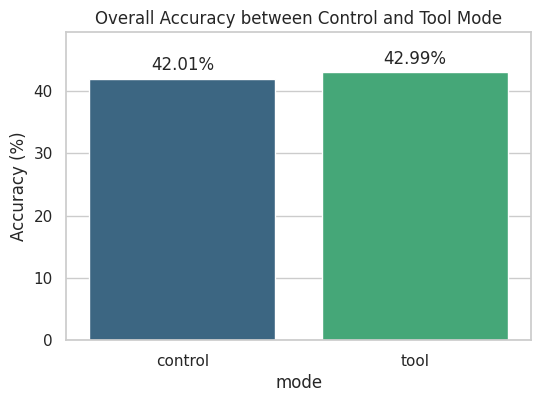

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# 1. Prepare the base data
overall_accuracy = df_q.groupby('mode')['is_correct'].agg(['mean', 'sum', 'count']).reset_index()
overall_accuracy.rename(columns={'mean': 'accuracy', 'sum': 'correct_answers', 'count': 'total_attempted'}, inplace=True)

# Extract counts for the Z-test
successes = overall_accuracy['correct_answers'].values
trials = overall_accuracy['total_attempted'].values

# Convert accuracy to percentage for display
overall_accuracy['accuracy'] = (overall_accuracy['accuracy'] * 100).round(2)

# 2. Perform the Two-Proportion Z-Test and create a summary table
if len(overall_accuracy) == 2:
    # Ensure consistent order (e.g., Control then Tool)
    overall_accuracy = overall_accuracy.sort_values(by='mode').reset_index(drop=True)
    
    mode1_name = overall_accuracy.iloc[0]['mode']
    mode2_name = overall_accuracy.iloc[1]['mode']
    
    acc1 = overall_accuracy.iloc[0]['accuracy']
    acc2 = overall_accuracy.iloc[1]['accuracy']
    
    n1 = overall_accuracy.iloc[0]['total_attempted']
    n2 = overall_accuracy.iloc[1]['total_attempted']
    
    # Run the Z-Test
    z_stat, p_value = proportions_ztest(count=successes, nobs=trials)
    
    # Calculate difference in percentage points
    diff = acc2 - acc1
    
    # Create the results table
    results_df = pd.DataFrame([{
        'Comparison': f'{mode1_name} vs {mode2_name}',
        f'{mode1_name} Acc (%)': acc1,
        f'{mode2_name} Acc (%)': acc2,
        f'{mode1_name} (N)': n1,
        f'{mode2_name} (N)': n2,
        'Diff (% pts)': round(diff, 2),
        'Z-Score': round(z_stat, 4),
        'P-Value': p_value,
        'Significant?': 'Yes' if p_value < 0.05 else 'No'
    }])
    
    print("--- Overall Statistical Test Results ---")
    display(results_df)

else:
    print("--- Accuracy Table ---")
    display(overall_accuracy)
    print("\nNote: Z-test requires exactly 2 groups to compare.")

print("\n")

# 3. Plot the Graph
plt.figure(figsize=(6,4))
ax = sns.barplot(data=overall_accuracy, x='mode', y='accuracy', palette='viridis')

# Iterate through the containers and add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Overall Accuracy between Control and Tool Mode')
plt.ylabel('Accuracy (%)')

# Expand the y-axis limit slightly so the text doesn't get cut off at the top
plt.ylim(0, overall_accuracy['accuracy'].max() * 1.15) 

plt.show()

## 1.2 Compare category accuracy: All

--- Category Accuracy & Z-Test Results ---


,Category,control Acc (%),tool Acc (%),control (N),tool (N),Diff (% pts),Z-Score,P-Value,Significant?
0,"Arts, Literature & Museums",17.65,20.00,17,20,2.35,-0.1821,0.855494,No
1,Geography & Travel,40.00,52.94,25,17,12.94,-0.8271,0.408187,No
2,History & Politics,88.89,73.33,27,15,-15.56,1.2961,0.194924,No
3,"Language, Linguistics & Cryptography",37.93,41.94,29,31,4.01,-0.3164,0.751696,No
4,Other,66.67,0.00,3,3,-66.67,1.7321,0.083265,No
5,Pop Culture & Entertainment,48.94,43.55,47,62,-5.39,0.5591,0.576122,No
6,Science & Mathematics,41.07,45.37,336,324,4.30,-1.1146,0.265001,No
7,Technology & Computer Science,31.51,31.43,73,70,-0.08,0.0101,0.991960,No


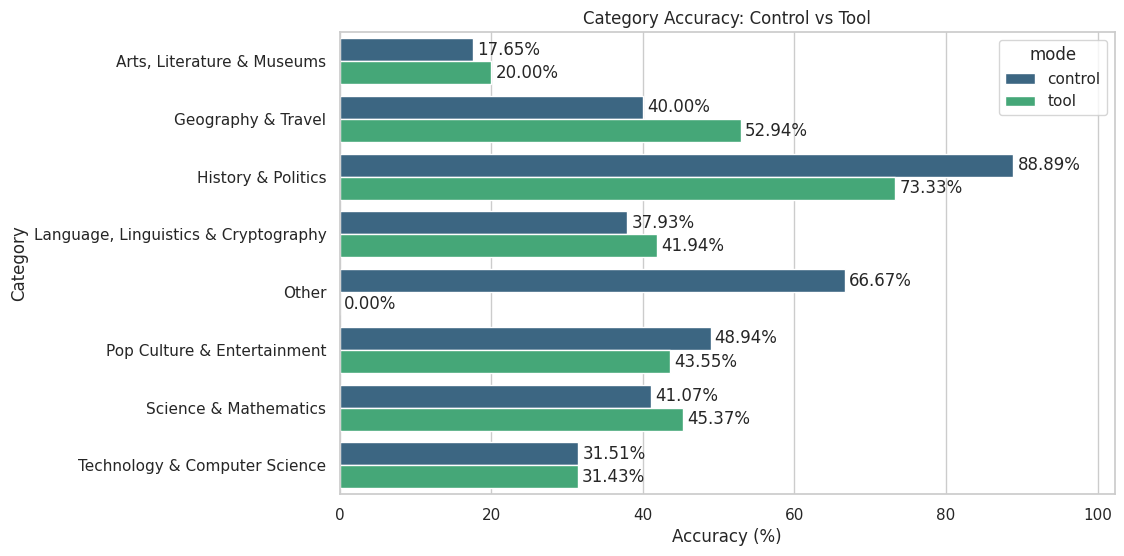

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# 1. Calculate the base statistics (including 'sum' for the Z-test)
cat_acc = df_q.groupby(['category', 'mode'])['is_correct'].agg(['mean', 'sum', 'count']).reset_index()
cat_acc.rename(columns={'mean': 'accuracy', 'sum': 'correct', 'count': 'attempted'}, inplace=True)
cat_acc['accuracy'] = (cat_acc['accuracy'] * 100).round(2)

# 2. Perform the Z-Test for each category and build a results table
test_results = []
categories = cat_acc['category'].unique()

for cat in categories:
    # Get data for the specific category
    cat_data = cat_acc[cat_acc['category'] == cat]
    
    # Ensure we have exactly 2 modes to compare
    if len(cat_data['mode'].unique()) == 2:
        # Sort to ensure consistent order (e.g., Control then Tool)
        cat_data = cat_data.sort_values(by='mode')
        
        mode1_name = cat_data.iloc[0]['mode']
        mode2_name = cat_data.iloc[1]['mode']
        
        acc1 = cat_data.iloc[0]['accuracy']
        acc2 = cat_data.iloc[1]['accuracy']
        
        n1 = cat_data.iloc[0]['attempted']
        n2 = cat_data.iloc[1]['attempted']
        
        successes = [cat_data.iloc[0]['correct'], cat_data.iloc[1]['correct']]
        trials = [n1, n2]
        
        # Two-Proportion Z-Test
        z_stat, p_value = proportions_ztest(count=successes, nobs=trials)
        
        # Difference in percentage points
        diff = acc2 - acc1
        
        test_results.append({
            'Category': cat,
            f'{mode1_name} Acc (%)': acc1,
            f'{mode2_name} Acc (%)': acc2,
            f'{mode1_name} (N)': n1,
            f'{mode2_name} (N)': n2,
            'Diff (% pts)': round(diff, 2),
            'Z-Score': round(z_stat, 4),
            'P-Value': p_value,
            'Significant?': 'Yes' if p_value < 0.05 else 'No'
        })

# Create and display the statistical results table
results_df = pd.DataFrame(test_results)
print("--- Category Accuracy & Z-Test Results ---")
display(results_df)

print("\n")

# 3. Plot the original graph with values added
plt.figure(figsize=(10,6))
# Assign the plot to 'ax'
ax = sns.barplot(data=cat_acc, x='accuracy', y='category', hue='mode', palette='viridis')

# Iterate through the containers (each hue group) and add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Category Accuracy: Control vs Tool')
plt.xlabel('Accuracy (%)')
plt.ylabel('Category')

# Expand the x-axis limit slightly so the text doesn't get cut off on the right side
plt.xlim(0, cat_acc['accuracy'].max() * 1.15)

plt.show()

## 1.3 Compare question category selection: All

This checks if the agent tends to select different categories of questions when playing in the `tool` mode compared to the baseline `control` mode.

OVERALL CATEGORY DISTRIBUTION TEST (Chi-Square)
p-value: 3.8803e-01 (0.3880)
Conclusion: No significant difference in the overall distribution of categories.

PER-CATEGORY DIFFERENCE TABLE:


,Category,control (%),tool (%),Difference (%),p-value,Significant
5,Pop Culture & Entertainment,8.44,11.44,3.00,0.096100,No
2,History & Politics,4.85,2.77,-2.08,0.072170,No
1,Geography & Travel,4.49,3.14,-1.35,0.242554,No
0,"Arts, Literature & Museums",3.05,3.69,0.64,0.557724,No
6,Science & Mathematics,60.32,59.78,-0.54,0.853797,No
3,"Language, Linguistics & Cryptography",5.21,5.72,0.51,0.708168,No
7,Technology & Computer Science,13.11,12.92,-0.19,0.925114,No
4,Other,0.54,0.55,0.01,0.973254,No


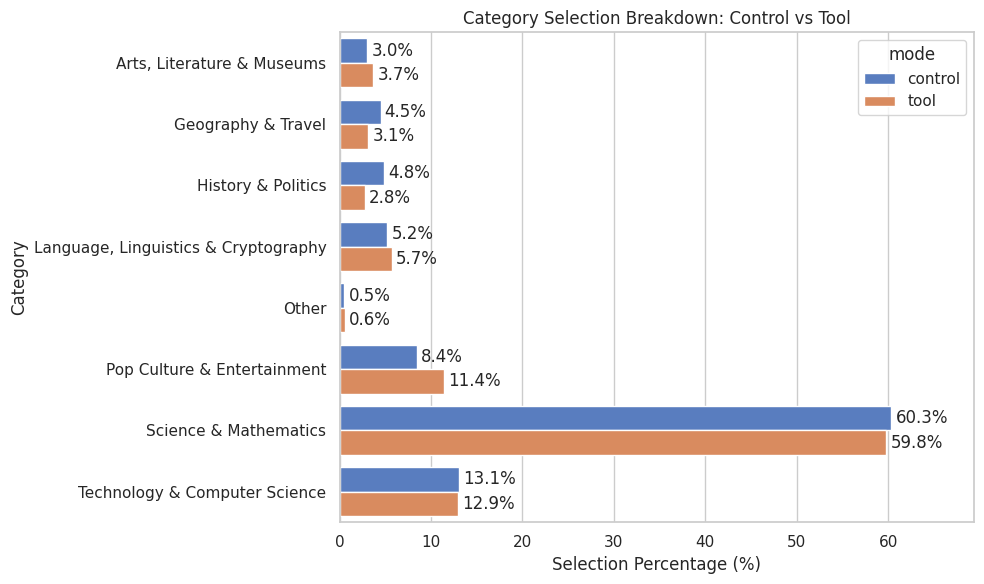

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# 1. Prepare the basic long-format data
cat_selection = df_q.groupby(['mode', 'category']).size().reset_index(name='selection_count')
total_per_mode = df_q.groupby('mode').size().reset_index(name='total')
cat_selection = pd.merge(cat_selection, total_per_mode, on='mode')
cat_selection['percentage'] = (cat_selection['selection_count'] / cat_selection['total'] * 100).round(2)

# 2. Overall Chi-Square Test for the entire distribution
contingency_table = pd.crosstab(df_q['category'], df_q['mode'])
chi2_stat, p_global, dof, expected = chi2_contingency(contingency_table)

print("="*60)
print("OVERALL CATEGORY DISTRIBUTION TEST (Chi-Square)")
print(f"p-value: {p_global:.4e} ({p_global:.4f})")
if p_global < 0.05:
    print("Conclusion: The overall distribution of categories is significantly different between modes.")
else:
    print("Conclusion: No significant difference in the overall distribution of categories.")
print("="*60 + "\n")

# 3. Create the Difference Table with Per-Category Z-Tests
modes = contingency_table.columns.tolist()
if len(modes) == 2:
    m1, m2 = modes[0], modes[1]  # e.g., 'Control' and 'Tool'
    totals = contingency_table.sum(axis=0)
    
    results = []
    for cat in contingency_table.index:
        count1 = contingency_table.loc[cat, m1]
        count2 = contingency_table.loc[cat, m2]
        nobs1 = totals[m1]
        nobs2 = totals[m2]
        
        pct1 = (count1 / nobs1) * 100
        pct2 = (count2 / nobs2) * 100
        diff = pct2 - pct1  # Difference (Mode 2 - Mode 1)
        
        # Two-Proportion Z-test for this specific category
        # It compares the proportion of times THIS category was picked vs ALL OTHER categories
        z_stat, p_val = proportions_ztest([count1, count2], [nobs1, nobs2])
        
        # Determine significance marker explicitly
        if pd.isna(p_val):
            sig = "N/A"
        elif p_val < 0.05:
            sig = "Yes"
        else:
            sig = "No"
        
        results.append({
            'Category': cat,
            f'{m1} (%)': round(pct1, 2),
            f'{m2} (%)': round(pct2, 2),
            'Difference (%)': round(diff, 2),
            'p-value': p_val,
            'Significant': sig
        })
        
    diff_table = pd.DataFrame(results)
    
    print("PER-CATEGORY DIFFERENCE TABLE:")
    # Sort by the absolute difference to see the biggest changes at the top
    diff_table_sorted = diff_table.reindex(diff_table['Difference (%)'].abs().sort_values(ascending=False).index)
    display(diff_table_sorted)
else:
    print("Note: Difference table requires exactly 2 modes.")

# 4. Plot the chart
plt.figure(figsize=(10,6))
ax = sns.barplot(data=cat_selection, x='percentage', y='category', hue='mode', palette='muted')

# Optional: Add percentage labels to the bars for easier reading
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Category Selection Breakdown: Control vs Tool')
plt.xlabel('Selection Percentage (%)')
plt.ylabel('Category')

# Expand x-axis slightly to fit the labels
plt.xlim(0, cat_selection['percentage'].max() * 1.15)

plt.tight_layout()
plt.show()

## 1.4 Compare question selection (based off level): All

OVERALL CATEGORY DISTRIBUTION TEST (Chi-Square)
p-value: 3.8803e-01 (0.3880)
Conclusion: No significant difference in the overall distribution of categories.

--- PER-CATEGORY SELECTION DIFFERENCE TABLE ---


,Category,control (%),tool (%),control (Count/N),tool (Count/N),Diff (% pts),Z-Score,P-Value,Significant?
5,Pop Culture & Entertainment,8.44,11.44,47/557,62/542,3.00,-1.6641,0.096100,No
2,History & Politics,4.85,2.77,27/557,15/542,-2.08,1.7980,0.072170,No
1,Geography & Travel,4.49,3.14,25/557,17/542,-1.35,1.1686,0.242554,No
0,"Arts, Literature & Museums",3.05,3.69,17/557,20/542,0.64,-0.5862,0.557724,No
6,Science & Mathematics,60.32,59.78,336/557,324/542,-0.54,0.1843,0.853797,No
3,"Language, Linguistics & Cryptography",5.21,5.72,29/557,31/542,0.51,-0.3743,0.708168,No
7,Technology & Computer Science,13.11,12.92,73/557,70/542,-0.19,0.0940,0.925114,No
4,Other,0.54,0.55,3/557,3/542,0.01,-0.0335,0.973254,No


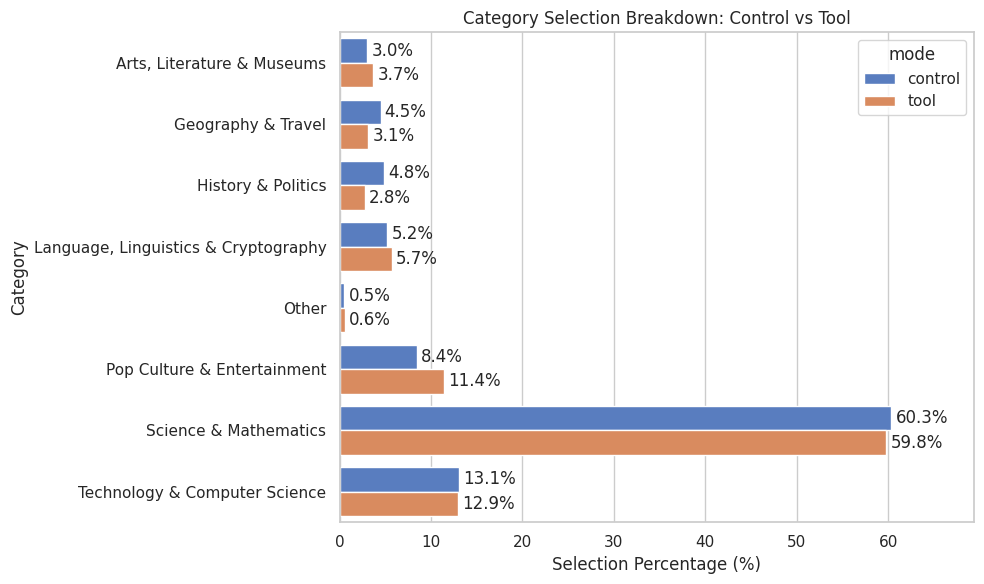

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# 1. Prepare the basic long-format data
cat_selection = df_q.groupby(['mode', 'category']).size().reset_index(name='selection_count')
total_per_mode = df_q.groupby('mode').size().reset_index(name='total')
cat_selection = pd.merge(cat_selection, total_per_mode, on='mode')
cat_selection['percentage'] = (cat_selection['selection_count'] / cat_selection['total'] * 100).round(2)

# 2. Overall Chi-Square Test for the entire distribution
contingency_table = pd.crosstab(df_q['category'], df_q['mode'])
chi2_stat, p_global, dof, expected = chi2_contingency(contingency_table)

print("="*60)
print("OVERALL CATEGORY DISTRIBUTION TEST (Chi-Square)")
print(f"p-value: {p_global:.4e} ({p_global:.4f})")
if p_global < 0.05:
    print("Conclusion: The overall distribution of categories is significantly different between modes.")
else:
    print("Conclusion: No significant difference in the overall distribution of categories.")
print("="*60 + "\n")

# 3. Create the Difference Table with Per-Category Z-Tests
modes = contingency_table.columns.tolist()
if len(modes) == 2:
    m1, m2 = modes[0], modes[1]  # e.g., 'Control' and 'Tool'
    totals = contingency_table.sum(axis=0)
    
    results = []
    for cat in contingency_table.index:
        count1 = contingency_table.loc[cat, m1]
        count2 = contingency_table.loc[cat, m2]
        nobs1 = totals[m1]
        nobs2 = totals[m2]
        
        pct1 = (count1 / nobs1) * 100
        pct2 = (count2 / nobs2) * 100
        diff = pct2 - pct1  # Difference (Mode 2 - Mode 1)
        
        # Two-Proportion Z-test for this specific category
        z_stat, p_val = proportions_ztest([count1, count2], [nobs1, nobs2])
        
        # Determine significance marker explicitly
        if pd.isna(p_val):
            sig = "N/A"
        elif p_val < 0.05:
            sig = "Yes"
        else:
            sig = "No"
        
        results.append({
            'Category': cat,
            f'{m1} (%)': round(pct1, 2),
            f'{m2} (%)': round(pct2, 2),
            f'{m1} (Count/N)': f"{count1}/{nobs1}",
            f'{m2} (Count/N)': f"{count2}/{nobs2}",
            'Diff (% pts)': round(diff, 2),
            'Z-Score': round(z_stat, 4) if not pd.isna(z_stat) else "N/A",
            'P-Value': p_val,
            'Significant?': sig
        })
        
    diff_table = pd.DataFrame(results)
    
    print("--- PER-CATEGORY SELECTION DIFFERENCE TABLE ---")
    # Sort by the absolute difference to see the biggest changes at the top
    diff_table_sorted = diff_table.reindex(diff_table['Diff (% pts)'].abs().sort_values(ascending=False).index)
    display(diff_table_sorted)
else:
    print("Note: Difference table requires exactly 2 modes.")

print("\n")

# 4. Plot the chart
plt.figure(figsize=(10,6))
ax = sns.barplot(data=cat_selection, x='percentage', y='category', hue='mode', palette='muted')

# Add percentage labels to the bars for easier reading
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Category Selection Breakdown: Control vs Tool')
plt.xlabel('Selection Percentage (%)')
plt.ylabel('Category')

# Expand x-axis slightly to fit the labels
plt.xlim(0, cat_selection['percentage'].max() * 1.15)

plt.tight_layout()
plt.show()

## 1.5 Compare accuracy across different levels: Both modes

OVERALL ACCURACY TEST (Chi-Square)
p-value: 7.8952e-01 (0.7895)
Conclusion: No significant difference in overall accuracy between modes.

--- PER-LEVEL ACCURACY DIFFERENCE TABLE ---


,Level,tool Acc (%),control Acc (%),tool (Correct/N),control (Correct/N),Diff (% pts),Z-Score,P-Value,Significant?
0,1,58.67,53.48,88/150,100/187,-5.19,0.9535,0.340318,No
2,2,38.84,36.11,94/242,91/252,-2.73,0.6271,0.530567,No
1,3,34.00,36.44,51/150,43/118,2.44,-0.4156,0.677667,No


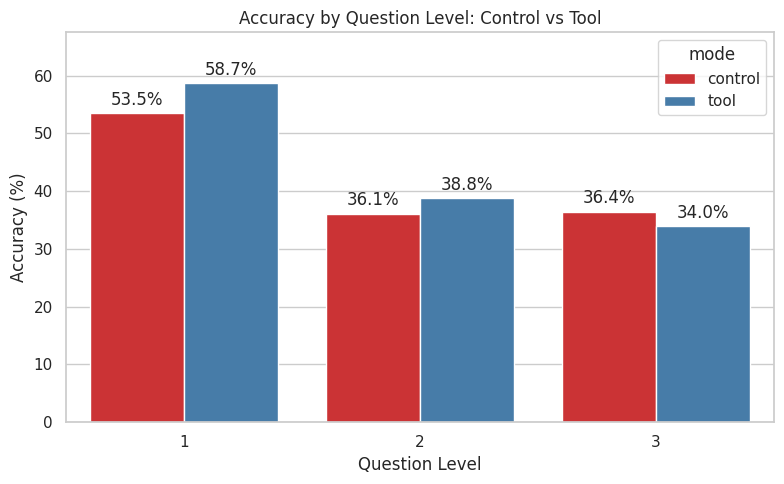

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# 1. Prepare the data (Adding 'sum' to get the exact count of correct answers)
level_acc = df_q.groupby(['mode', 'level'])['is_correct'].agg(['mean', 'count', 'sum']).reset_index()
level_acc.rename(columns={'mean': 'accuracy', 'count': 'attempted', 'sum': 'correct_count'}, inplace=True)
level_acc['accuracy'] = (level_acc['accuracy'] * 100).round(2)

# 2. Overall Accuracy Test (Chi-Square for all questions combined)
contingency_table_acc = pd.crosstab(df_q['is_correct'], df_q['mode'])
chi2_stat_acc, p_global_acc, dof_acc, expected_acc = chi2_contingency(contingency_table_acc)

print("="*60)
print("OVERALL ACCURACY TEST (Chi-Square)")
print(f"p-value: {p_global_acc:.4e} ({p_global_acc:.4f})")
if p_global_acc < 0.05:
    print("Conclusion: There is a significant difference in overall accuracy between modes.")
else:
    print("Conclusion: No significant difference in overall accuracy between modes.")
print("="*60 + "\n")

# 3. Create the Difference Table with Per-Level Z-Tests
modes = df_q['mode'].unique().tolist()
if len(modes) == 2:
    m1, m2 = modes[0], modes[1]  # e.g., 'Control' and 'Tool'
    levels = df_q['level'].unique()
    
    results_acc = []
    for lvl in levels:
        # Get stats for Mode 1
        m1_data = level_acc[(level_acc['mode'] == m1) & (level_acc['level'] == lvl)]
        count1 = m1_data['correct_count'].values[0] if not m1_data.empty else 0
        nobs1 = m1_data['attempted'].values[0] if not m1_data.empty else 0
        pct1 = m1_data['accuracy'].values[0] if not m1_data.empty else 0.0
        
        # Get stats for Mode 2
        m2_data = level_acc[(level_acc['mode'] == m2) & (level_acc['level'] == lvl)]
        count2 = m2_data['correct_count'].values[0] if not m2_data.empty else 0
        nobs2 = m2_data['attempted'].values[0] if not m2_data.empty else 0
        pct2 = m2_data['accuracy'].values[0] if not m2_data.empty else 0.0
        
        diff = pct2 - pct1  # Difference (Mode 2 - Mode 1)
        
        # Two-Proportion Z-test for accuracy in this specific level
        z_stat = float('nan')
        if nobs1 > 0 and nobs2 > 0:
            z_stat, p_val = proportions_ztest([count1, count2], [nobs1, nobs2])
        else:
            p_val = float('nan')
        
        # Determine significance marker explicitly
        if pd.isna(p_val):
            sig = "N/A"
        elif p_val < 0.05:
            sig = "Yes"
        else:
            sig = "No"
        
        results_acc.append({
            'Level': lvl,
            f'{m1} Acc (%)': round(pct1, 2),
            f'{m2} Acc (%)': round(pct2, 2),
            f'{m1} (Correct/N)': f"{int(count1)}/{int(nobs1)}",
            f'{m2} (Correct/N)': f"{int(count2)}/{int(nobs2)}",
            'Diff (% pts)': round(diff, 2),
            'Z-Score': round(z_stat, 4) if not pd.isna(z_stat) else "N/A",
            'P-Value': p_val,
            'Significant?': sig
        })
        
    diff_table_acc = pd.DataFrame(results_acc)
    
    print("--- PER-LEVEL ACCURACY DIFFERENCE TABLE ---")
    # Sort by the absolute difference to see the biggest accuracy changes at the top
    diff_table_acc_sorted = diff_table_acc.reindex(diff_table_acc['Diff (% pts)'].abs().sort_values(ascending=False).index)
    display(diff_table_acc_sorted)
else:
    print("Note: Difference table requires exactly 2 modes.")

print("\n")

# 4. Plot the chart
plt.figure(figsize=(8,5))
ax = sns.barplot(data=level_acc, x='level', y='accuracy', hue='mode', palette='Set1')
plt.title('Accuracy by Question Level: Control vs Tool')
plt.xlabel('Question Level')
plt.ylabel('Accuracy (%)')

# Add percentage labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Expand y-axis slightly to fit the labels
plt.ylim(0, level_acc['accuracy'].max() * 1.15)
plt.tight_layout()
plt.show()